# **Data Preparation Notebook **

## Objectives

* Prepare data for model training
  * Impute missing values
  * Ensure categorical variables are encoded
  * Consider dropping outliers 

## Inputs

outputs/datasets/collection/house_prices

## Outputs

outputs/datasets/cleaned/house_prices


---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [3]:
import os
current_dir = os.getcwd()
current_dir

'/workspaces/heritage-housing-issues-milestone/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [4]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [5]:
current_dir = os.getcwd()
current_dir

'/workspaces/heritage-housing-issues-milestone'

# Data Preparation



In [6]:
import pandas as pd
df = pd.read_csv(f"outputs/datasets/collection/house_prices")
df.head()

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GarageYrBlt,...,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,548,RFn,2003.0,...,8450,65.0,196.0,61,5,7,856,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,460,RFn,1976.0,...,9600,80.0,0.0,0,8,6,1262,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,608,RFn,2001.0,...,11250,68.0,162.0,42,5,7,920,2001,2002,223500
3,961,NaN,NaN,No,216,ALQ,540,642,Unf,1998.0,...,9550,60.0,0.0,35,5,7,756,1915,1970,140000
4,1145,NaN,4.0,Av,655,GLQ,490,836,RFn,2000.0,...,14260,84.0,350.0,84,5,8,1145,2000,2000,250000


---

# Missing Values

In [7]:
# Display a table to visualise null data
null_data = []

for col in df.columns:
    null_count = df[col].isnull().sum()
    if null_count > 0:
        null_data.append({
            'Variable': col,
            'Null Count': null_count,
            'Null %': round(null_count / len(df) * 100, 1),
            'Data Type': 'Numerical' if df[col].dtype in ['int64', 'float64'] else 'Categorical'
        })

null_df = pd.DataFrame(null_data).sort_values('Null %', ascending=False)
print(null_df.to_string(index=False))

    Variable  Null Count  Null %   Data Type
 LotFrontage         259    17.7   Numerical
GarageFinish         235    16.1 Categorical
BsmtFinType1         145     9.9 Categorical
BedroomAbvGr          99     6.8   Numerical
    2ndFlrSF          86     5.9   Numerical
 GarageYrBlt          81     5.5   Numerical
BsmtExposure          38     2.6 Categorical
  MasVnrArea           8     0.5   Numerical


We will be imputing missing data for the following reasons:
* To avoid loss of statistical power, compared to dropping rows with null values
* To reduce bias
* Ensure compatability with algorithms

We have chosen to impute median values for numerical values. The reasoning behind this is housing attributes data is likely to be skewed, with a small number of large properties affecting the mode. For this reason, we will be using median.

With categorical values, we will be imputing the mode value.



In [8]:
from sklearn.impute import SimpleImputer

# Median imputation for numerical variables
median_imputer = SimpleImputer(strategy='median')
median_cols = ['LotFrontage', 'GarageYrBlt', 'BedroomAbvGr', '2ndFlrSF', 'MasVnrArea']
df[median_cols] = median_imputer.fit_transform(df[median_cols])

# Mode imputation for categorical variables
mode_imputer = SimpleImputer(strategy='most_frequent')
mode_cols = ['BsmtExposure', 'BsmtFinType1', 'GarageFinish']
df[mode_cols] = mode_imputer.fit_transform(df[mode_cols])

# Confirm no null values remain
print(df.isnull().sum())

1stFlrSF        0
2ndFlrSF        0
BedroomAbvGr    0
BsmtExposure    0
BsmtFinSF1      0
BsmtFinType1    0
BsmtUnfSF       0
GarageArea      0
GarageFinish    0
GarageYrBlt     0
GrLivArea       0
KitchenQual     0
LotArea         0
LotFrontage     0
MasVnrArea      0
OpenPorchSF     0
OverallCond     0
OverallQual     0
TotalBsmtSF     0
YearBuilt       0
YearRemodAdd    0
SalePrice       0
dtype: int64


---

## Encode Categorical Values

As in Notebook 2, we will encode categorical values to ensure compliance with algorithms.

In [9]:
from feature_engine.encoding import OrdinalEncoder


encoder = OrdinalEncoder(
    encoding_method='arbitrary',
    variables=['KitchenQual', 'BsmtExposure', 'BsmtFinType1', 'GarageFinish'],
    missing_values='ignore'
)


df_encoded = encoder.fit_transform(df)
print(df_encoded.shape)
df_encoded.head(5)

(1460, 22)


/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(X[feature]):
/home/cistudent/.local/lib/python3.12/site-packages/feature_engine/encoding/base_encoder.py:223: FutureWarning: is_categorical_dtype is 

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GarageYrBlt,...,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,0,706,0,150,548,0,2003.0,...,8450,65.0,196.0,61,5,7,856,2003,2003,208500
1,1262,0.0,3.0,1,978,1,284,460,0,1976.0,...,9600,80.0,0.0,0,8,6,1262,1976,1976,181500
2,920,866.0,3.0,2,486,0,434,608,0,2001.0,...,11250,68.0,162.0,42,5,7,920,2001,2002,223500
3,961,0.0,3.0,0,216,1,540,642,1,1998.0,...,9550,60.0,0.0,35,5,7,756,1915,1970,140000
4,1145,0.0,4.0,3,655,0,490,836,0,2000.0,...,14260,84.0,350.0,84,5,8,1145,2000,2000,250000


---

## Handling outliers

It is worth considering whether to drop or retain outliers when preparing data for model training. 

First we will explore and visualise outlying data using a histogram, and sceondly calculate the number of percentage and outliers.

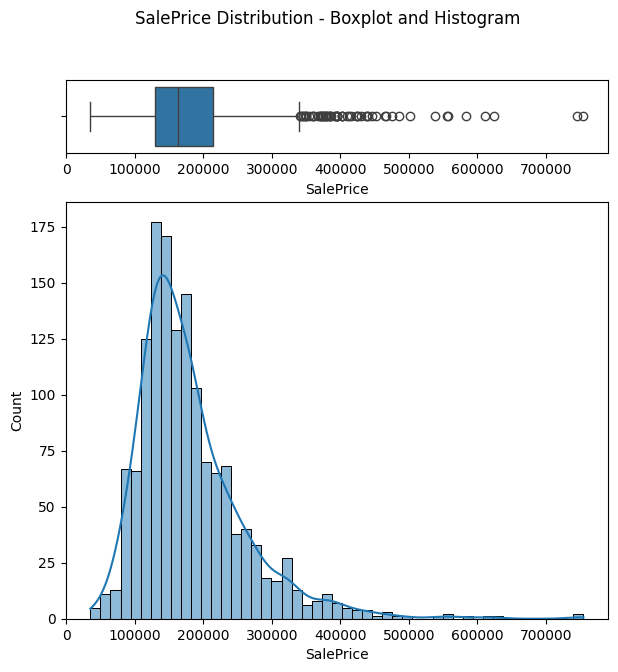

This is the range where a datapoint is not an outlier: from 3937.5 to 340037.5




In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# This code was taken and modified from Feature Engine Unit 6 of Code Institute's Full Stack program.
def plot_histogram_and_boxplot(df, col):
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 7), 
                             gridspec_kw={"height_ratios": (.15, .85)})
    sns.boxplot(data=df, x=col, ax=axes[0])
    sns.histplot(data=df, x=col, kde=True, ax=axes[1])
    fig.suptitle(f"{col} Distribution - Boxplot and Histogram")
    plt.show()
    
    IQR = df[col].quantile(q=0.75) - df[col].quantile(q=0.25)
    print(
        f"This is the range where a datapoint is not an outlier: from "
        f"{(df[col].quantile(q=0.25) - 1.5*IQR).round(2)} to "
        f"{(df[col].quantile(q=0.75) + 1.5*IQR).round(2)}"
    )
    print("\n")

plot_histogram_and_boxplot(df, 'SalePrice')

In [11]:
lower_bound = 3937.5
upper_bound = 340037.5

outliers = df[(df['SalePrice'] < lower_bound) | (df['SalePrice'] > upper_bound)]

print(f"Number of outliers: {len(outliers)}")
print(f"Percentage of dataset: {round(len(outliers) / len(df) * 100, 1)}%")

Number of outliers: 61
Percentage of dataset: 4.2%


## Observations and Conclusion on handling outliers

We consider the following:
* The range where a datapoint is not an outlier: from 3937.5 to 340037.5
* Number of outliers: 61
* Percentage of dataset: 4.2%

4.2% is a small enough percentage to consider dropping, however we have decided to include outliers initially for the following reasons:
* Real life houses vary as reflected in the dataset, which we want to account for in our model.
* We are expecting to use a Random Forest model, which handles outliers well.
* Dropping data would restrict our dataset.

We will return to this decision if we encounter issues with our model training.




# Push files to Repo

We will now save our cleaned data set 

In [ ]:
# Check dataframe before saving
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   1stFlrSF      1460 non-null   int64  
 1   2ndFlrSF      1460 non-null   float64
 2   BedroomAbvGr  1460 non-null   float64
 3   BsmtExposure  1460 non-null   int64  
 4   BsmtFinSF1    1460 non-null   int64  
 5   BsmtFinType1  1460 non-null   int64  
 6   BsmtUnfSF     1460 non-null   int64  
 7   GarageArea    1460 non-null   int64  
 8   GarageFinish  1460 non-null   int64  
 9   GarageYrBlt   1460 non-null   float64
 10  GrLivArea     1460 non-null   int64  
 11  KitchenQual   1460 non-null   int64  
 12  LotArea       1460 non-null   int64  
 13  LotFrontage   1460 non-null   float64
 14  MasVnrArea    1460 non-null   float64
 15  OpenPorchSF   1460 non-null   int64  
 16  OverallCond   1460 non-null   int64  
 17  OverallQual   1460 non-null   int64  
 18  TotalBsmtSF   1460 non-null 

In [12]:
# Create collections folder and save cleaned dataset
import os
try:
    os.makedirs(name='outputs/datasets/cleaned')
except Exception as e:
    print(e)

df_encoded.to_csv('outputs/datasets/cleaned/house_prices', index=False)